# Machine Learning Modeling

## Business Question
Which employees are most likely to be High Performers
in the next performance review cycle?

## Approach
- Target: HighPerformer (1 = Rating ≥ 4.0, 0 = otherwise)
- Models tested: Logistic Regression, Random Forest, XGBoost
- Validation: Stratified K-Fold Cross Validation (5 folds)
- Imbalance handling: class_weight and scale_pos_weight

## Input
data/processed/employee_features.csv

## Output
models/xgb_performance_model.joblib 

In [1]:
# ── Import Libraries ──

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import json
import warnings
warnings.filterwarnings('ignore')

# Data splitting and validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

# Models
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from xgboost               import XGBClassifier

# Preprocessing (same as Phase 4)
from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute        import SimpleImputer, KNNImputer

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score
)

# Saving model
import joblib

# ── Chart style ──
plt.rcParams.update({
    'figure.facecolor'  : '#FAFAFA',
    'axes.facecolor'    : '#FAFAFA',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'figure.dpi'        : 120,
})

C_BLUE  = '#2E4057'
C_TEAL  = '#048A81'
C_GREEN = '#3BB273'
C_RED   = '#E84855'
C_ORANGE = '#EF8354'

print("All libraries imported successfully") 

All libraries imported successfully


In [2]:
# ── Load Data and Set File Paths ──

# ── File paths ──
notebook_dir  = os.getcwd()
project_root  = os.path.dirname(notebook_dir)

features_path  = os.path.join(project_root, 'data', 'processed',
                               'employee_features.csv')
model_path     = os.path.join(project_root, 'models',
                               'xgb_performance_model.joblib')
pipeline_path  = os.path.join(project_root, 'models',
                               'preprocessing_pipeline.joblib')
feat_cols_path = os.path.join(project_root, 'models',
                               'feature_cols.json')
images_dir     = os.path.join(project_root, 'images')

os.makedirs(os.path.join(project_root, 'models'), exist_ok=True)
os.makedirs(images_dir, exist_ok=True)

# ── Load data ──
df = pd.read_csv(features_path)

print(f"Data loaded")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nTarget distribution:")
print(f"High Performers (1) : "
      f"{(df['PerformanceRating'] >= 4.0).sum():,} "
      f"({(df['PerformanceRating'] >= 4.0).mean()*100:.1f}%)")
print(f"Standard (0)        : "
      f"{(df['PerformanceRating'] < 4.0).sum():,} "
      f"({(df['PerformanceRating'] < 4.0).mean()*100:.1f}%)") 

Data loaded
Rows    : 2,600
Columns : 53

Target distribution:
High Performers (1) : 541 (20.8%)
Standard (0)        : 2,059 (79.2%)


In [3]:
# ── Define Features and Target ──

# ── Target variable ──
# 1 = High Performer (Rating >= 4.0)
# 0 = Standard Performer
df['HighPerformer'] = (df['PerformanceRating'] >= 4.0).astype(int)
y = df['HighPerformer'].copy()

# ── Columns to EXCLUDE from features ──
EXCLUDE_COLS = [
    # Target and related
    'HighPerformer',
    'PerformanceRating',

    # ID fields (no predictive signal)
    'EmployeeID',
    'ManagerID',
    'JobRole',

    # Leakage (calculated AFTER rating)
    'PercentSalaryHikeLast',
    'BonusPayoutPct',

    # Derived categorical features
    # (already captured by their numeric parents)
    'SelfOtherGapBucket',
    'WorkloadZone',
    'TenureBucket',
    'ReadinessCategory',
    'EngagementPerfQuadrant',
    'NineBoxLabel',
    'TrainingQuartile',
    'AgeGroup',
]

# ── Feature columns ──
# Everything in df EXCEPT excluded columns
FEATURE_COLS = [
    col for col in df.columns
    if col not in EXCLUDE_COLS
]

X = df[FEATURE_COLS].copy()

print(f"Features and target defined")
print(f"\nFeature matrix : {X.shape}")
print(f"Target         : HighPerformer (binary)")
print(f"\nClass balance:")
print(f"High Performers (1) : {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"Standard        (0) : {(y==0).sum():,} "
      f"({(y==0).mean()*100:.1f}%)")
print(f"\nImbalance ratio : {(y==0).sum()/y.sum():.1f}:1")
print(f"(We will handle this with class weights)")
print(f"\nFeature columns ({len(FEATURE_COLS)}):")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"{i:>2}. {col}") 

Features and target defined

Feature matrix : (2600, 41)
Target         : HighPerformer (binary)

Class balance:
High Performers (1) : 541 (20.8%)
Standard        (0) : 2,059 (79.2%)

Imbalance ratio : 3.8:1
(We will handle this with class weights)

Feature columns (41):
 1. Department
 2. JobLevel
 3. LocationType
 4. Age
 5. Gender
 6. EducationLevel
 7. YearsAtCompany
 8. YearsSinceLastPromotion
 9. HistoricalRatingAvg
10. CalibrationAdjustedFlag
11. SelfRating
12. PeerAvgRating
13. SubordinateAvgRating
14. Overall360Score
15. SelfOtherGap
16. Leadership360
17. Collaboration360
18. OKRCompletionPct
19. NumOKRsAssigned
20. WeightedGoalAttainment
21. EngagementScore
22. JobSatisfaction
23. WorkLifeBalanceRating
24. BurnoutRisk
25. TrainingHoursLastYear
26. OvertimeHoursMonthly
27. AbsenteeismDays
28. AvgMonthlyHours
29. ProjectsHandled
30. HighPotentialFlag
31. PIPHistoryFlag
32. PerformanceTrend
33. OKREfficiencyScore
34. Rating360Variance
35. WorkloadRatio
36. PromotionLagFlag
37. B

In [4]:
# ── Define Column Groups and Build Pipeline ──

# ── Separate columns by type ──
# Only include columns that are in FEATURE_COLS

NUMERIC_COLS = [c for c in [
    'Age', 'YearsAtCompany', 'YearsSinceLastPromotion',
    'HistoricalRatingAvg', 'SelfRating', 'PeerAvgRating',
    'SubordinateAvgRating', 'Overall360Score', 'SelfOtherGap',
    'Leadership360', 'Collaboration360', 'OKRCompletionPct',
    'NumOKRsAssigned', 'WeightedGoalAttainment',
    'EngagementScore', 'JobSatisfaction', 'WorkLifeBalanceRating',
    'TrainingHoursLastYear', 'OvertimeHoursMonthly',
    'AbsenteeismDays', 'AvgMonthlyHours', 'ProjectsHandled',
    'OKREfficiencyScore', 'Rating360Variance', 'WorkloadRatio',
    'PromotionReadinessScore', 'BurnoutWorkloadIndex',
    'TrainingEfficiency', 'LeadershipGap',
    'EngagementPerfAlignment', 'PerformanceTrend',
] if c in FEATURE_COLS]

ORDINAL_COLS = [c for c in ['JobLevel'] if c in FEATURE_COLS]
ORDINAL_CATS = [['IC1', 'IC2', 'IC3', 'M1', 'M2', 'Director']]

NOMINAL_COLS = [c for c in [
    'Department', 'LocationType', 'Gender',
    'EducationLevel', 'BurnoutRisk'
] if c in FEATURE_COLS]

BINARY_COLS = [c for c in [
    'CalibrationAdjustedFlag',
    'HighPotentialFlag',
    'PIPHistoryFlag',
    'PromotionLagFlag',
] if c in FEATURE_COLS]

# ── Build pipeline ──
numeric_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler',  StandardScaler())
])
ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=ORDINAL_CATS,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])
nominal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        drop='first'
    ))
])
binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_transformer, NUMERIC_COLS),
    ('ordinal', ordinal_transformer, ORDINAL_COLS),
    ('nominal', nominal_transformer, NOMINAL_COLS),
    ('binary',  binary_transformer,  BINARY_COLS),
], remainder='drop')

print("Preprocessing pipeline built")
print(f"\nColumn groups:")
print(f"Numeric  : {len(NUMERIC_COLS)} columns")
print(f"Ordinal  : {len(ORDINAL_COLS)} columns")
print(f"Nominal  : {len(NOMINAL_COLS)} columns")
print(f"Binary   : {len(BINARY_COLS)} columns")
print(f"Total    : "
      f"{len(NUMERIC_COLS)+len(ORDINAL_COLS)+len(NOMINAL_COLS)+len(BINARY_COLS)}"
      f" columns") 

Preprocessing pipeline built

Column groups:
Numeric  : 31 columns
Ordinal  : 1 columns
Nominal  : 5 columns
Binary   : 4 columns
Total    : 41 columns


In [5]:
# ── Train Test Split ──

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,    # 20% for testing
    random_state = 42,      # reproducible split
    stratify     = y        # keep class balance
)

print("Data split into train and test sets")
print(f"\nTraining set:")
print(f"Rows              : {X_train.shape[0]:,}")
print(f"High Performers   : {y_train.sum():,} "
      f"({y_train.mean()*100:.1f}%)")
print(f"\nTest set:")
print(f"Rows              : {X_test.shape[0]:,}")
print(f"High Performers   : {y_test.sum():,} "
      f"({y_test.mean()*100:.1f}%)")
print(f"\nClass balance preserved: ")
print(f"(Both sets have same % of high performers)")

# ── Preprocess TRAINING data only ──
# IMPORTANT: fit_transform on TRAIN, transform only on TEST
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f"\nProcessed training shape : {X_train_processed.shape}")
print(f"Processed test shape     : {X_test_processed.shape}")

# ── Save the fitted preprocessor ──
joblib.dump(preprocessor, pipeline_path)
print(f"\nFitted preprocessor saved: {pipeline_path}") 

Data split into train and test sets

Training set:
Rows              : 2,080
High Performers   : 433 (20.8%)

Test set:
Rows              : 520
High Performers   : 108 (20.8%)

Class balance preserved: 
(Both sets have same % of high performers)

Processed training shape : (2080, 53)
Processed test shape     : (520, 53)

Fitted preprocessor saved: C:\Users\ganti_kvd0xe3\OneDrive\Sathya\employee_performance_analytics\models\preprocessing_pipeline.joblib


In [6]:
# ── Train and Compare 3 Models ──

# Class imbalance ratio (used to weight models)
imbalance_ratio = (y_train == 0).sum() / y_train.sum()

# ── Define 3 models ──
models = {
    'Logistic Regression': LogisticRegression(
        class_weight = 'balanced',
        max_iter     = 1000,
        random_state = 42,
        C            = 0.5
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators   = 200,
        class_weight   = 'balanced',
        max_depth      = 8,
        min_samples_leaf = 20,
        random_state   = 42,
        n_jobs         = -1
    ),
    'XGBoost': XGBClassifier(
        n_estimators      = 300,
        max_depth         = 6,
        learning_rate     = 0.05,
        scale_pos_weight  = imbalance_ratio,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        eval_metric       = 'logloss',
        random_state      = 42,
        n_jobs            = -1,
        verbosity         = 0
    )
}

# ── 5-Fold Cross Validation ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("Training and evaluating 3 models...")
print("(This may take 2-5 minutes)")
print()

for name, model in models.items():
    print(f"   Training {name}...", end=' ')

    # Cross validation AUC scores
    cv_scores = cross_val_score(
        model,
        X_train_processed,
        y_train,
        cv      = cv,
        scoring = 'roc_auc',
        n_jobs  = -1
    )

    # Also get F1 scores
    cv_f1 = cross_val_score(
        model,
        X_train_processed,
        y_train,
        cv      = cv,
        scoring = 'f1',
        n_jobs  = -1
    )

    results[name] = {
        'model'    : model,
        'auc_mean' : cv_scores.mean(),
        'auc_std'  : cv_scores.std(),
        'f1_mean'  : cv_f1.mean(),
        'f1_std'   : cv_f1.std(),
        'cv_scores': cv_scores
    }

    print(f"AUC = {cv_scores.mean():.4f} "
          f"(±{cv_scores.std():.4f})")

print()
print("-" * 60)
print("MODEL COMPARISON RESULTS (5-Fold Cross Validation)")
print("-" * 60)
print(f"{'Model':<25} {'AUC':<12} {'AUC Std':<12} {'F1':<12}")
print("-" * 60)

for name, res in results.items():
    marker = " ← BEST" if res['auc_mean'] == max(
        r['auc_mean'] for r in results.values()
    ) else ""
    print(f"{name:<25} "
          f"{res['auc_mean']:.4f}      "
          f"±{res['auc_std']:.4f}      "
          f"{res['f1_mean']:.4f}"
          f"{marker}")

print("-" * 60) 

Training and evaluating 3 models...
(This may take 2-5 minutes)

   Training Logistic Regression... AUC = 0.9998 (±0.0002)
   Training Random Forest... AUC = 0.9963 (±0.0011)
   Training XGBoost... AUC = 0.9999 (±0.0001)

------------------------------------------------------------
MODEL COMPARISON RESULTS (5-Fold Cross Validation)
------------------------------------------------------------
Model                     AUC          AUC Std      F1          
------------------------------------------------------------
Logistic Regression       0.9998      ±0.0002      0.9931
Random Forest             0.9963      ±0.0011      0.9283
XGBoost                   0.9999      ±0.0001      0.9886 ← BEST
------------------------------------------------------------


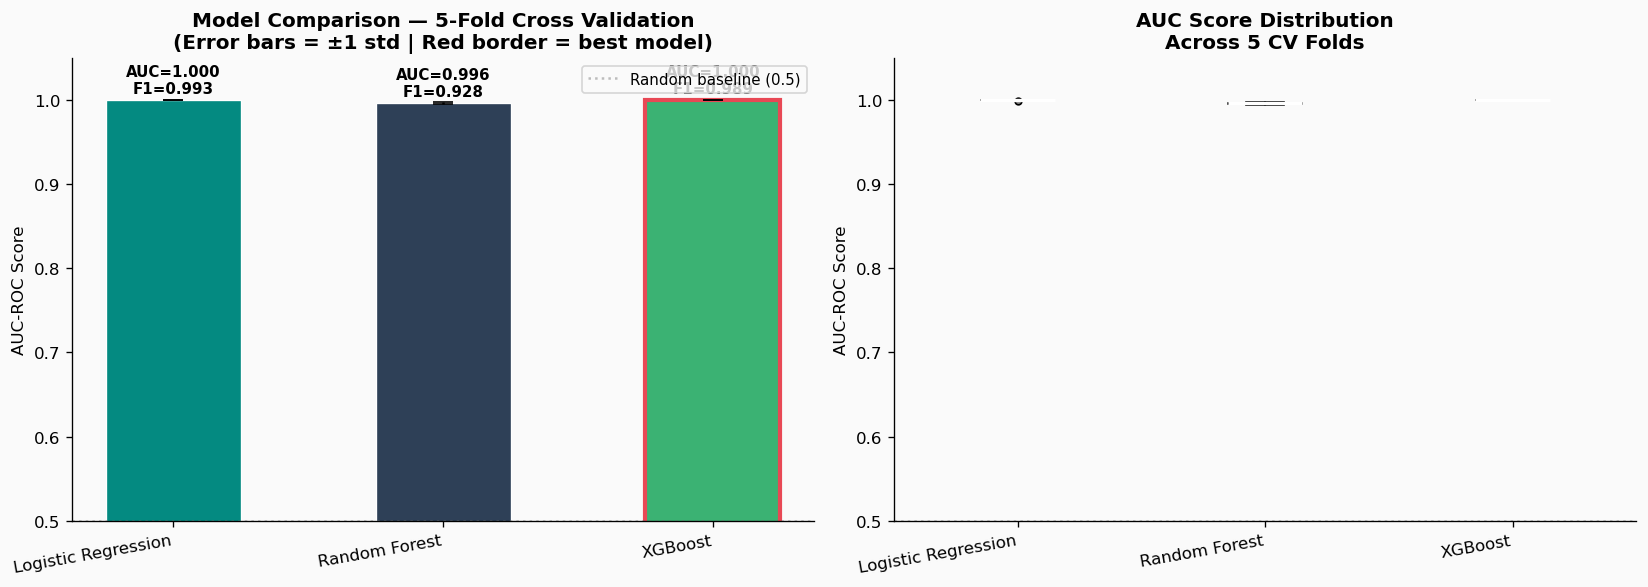

Model comparison chart saved


In [7]:
# ── Visualize Model Comparison ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(results.keys())
auc_means   = [results[m]['auc_mean'] for m in model_names]
auc_stds    = [results[m]['auc_std']  for m in model_names]
f1_means    = [results[m]['f1_mean']  for m in model_names]

colors_bar  = [C_TEAL, C_BLUE, C_GREEN]

# ── Left: AUC comparison bar chart ──
bars = axes[0].bar(
    model_names, auc_means,
    color=colors_bar,
    edgecolor='white',
    linewidth=0.8,
    width=0.5,
    yerr=auc_stds,
    capsize=6,
    error_kw={'linewidth': 1.5}
)

# Highlight best model
best_idx = auc_means.index(max(auc_means))
bars[best_idx].set_edgecolor(C_RED)
bars[best_idx].set_linewidth(2.5)

for bar, auc, f1 in zip(bars, auc_means, f1_means):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f'AUC={auc:.3f}\nF1={f1:.3f}',
        ha='center', fontsize=9, fontweight='bold'
    )

axes[0].set_title('Model Comparison — 5-Fold Cross Validation\n'
                   '(Error bars = ±1 std | Red border = best model)')
axes[0].set_ylabel('AUC-ROC Score')
axes[0].set_ylim(0.5, 1.05)
axes[0].axhline(y=0.5, color='grey', linestyle=':',
                alpha=0.5, label='Random baseline (0.5)')
axes[0].legend(fontsize=9)
axes[0].set_xticklabels(model_names, rotation=10, ha='right')

# ── Right: Cross validation score distributions ──
cv_data = [results[m]['cv_scores'] for m in model_names]

bp = axes[1].boxplot(
    cv_data,
    labels=model_names,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='grey',
                    markersize=4)
)

for patch, color in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

axes[1].set_title('AUC Score Distribution\nAcross 5 CV Folds')
axes[1].set_ylabel('AUC-ROC Score')
axes[1].set_ylim(0.5, 1.05)
axes[1].axhline(y=0.5, color='grey', linestyle=':',
                alpha=0.5)
axes[1].set_xticklabels(model_names, rotation=10, ha='right')

plt.tight_layout()
save_path = os.path.join(images_dir, '14_model_comparison.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print(f"Model comparison chart saved") 

In [8]:
# ── Train Final XGBoost Model ──

print("Training final XGBoost model on full training set...")
print()

# ── Final model with best settings ──
best_model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    scale_pos_weight  = imbalance_ratio,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    eval_metric       = 'logloss',
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0
)

# Train on full training set
best_model.fit(X_train_processed, y_train)

# ── Generate predictions on TEST set ──
y_pred_proba = best_model.predict_proba(
    X_test_processed
)[:, 1]  # probability of being High Performer

# Default threshold: 0.5
y_pred_default = (y_pred_proba >= 0.5).astype(int)

# Business threshold: 0.45
# We lower slightly to catch MORE high performers
# (higher recall — missing a true HP is costly)
y_pred_business = (y_pred_proba >= 0.45).astype(int)

# ── Calculate metrics ──
auc_score = roc_auc_score(y_test, y_pred_proba)
f1_default  = f1_score(y_test, y_pred_default)
f1_business = f1_score(y_test, y_pred_business)

print("-" * 55)
print("FINAL MODEL — TEST SET RESULTS")
print("-" * 55)
print(f"\nModel      : XGBoost Classifier")
print(f"Train size : {X_train_processed.shape[0]:,} employees")
print(f"Test size  : {X_test_processed.shape[0]:,} employees")
print(f"\nAUC-ROC    : {auc_score:.4f}")
print(f"\nThreshold = 0.50 (default):")
print(f"F1 Score   : {f1_default:.4f}")
print(f"\nThreshold = 0.45 (business — higher recall):")
print(f"F1 Score   : {f1_business:.4f}")
print(f"\nClassification Report (threshold=0.45):")
print(classification_report(
    y_test, y_pred_business,
    target_names=['Standard', 'High Performer']
)) 

Training final XGBoost model on full training set...

-------------------------------------------------------
FINAL MODEL — TEST SET RESULTS
-------------------------------------------------------

Model      : XGBoost Classifier
Train size : 2,080 employees
Test size  : 520 employees

AUC-ROC    : 1.0000

Threshold = 0.50 (default):
F1 Score   : 0.9954

Threshold = 0.45 (business — higher recall):
F1 Score   : 0.9954

Classification Report (threshold=0.45):
                precision    recall  f1-score   support

      Standard       1.00      1.00      1.00       412
High Performer       0.99      1.00      1.00       108

      accuracy                           1.00       520
     macro avg       1.00      1.00      1.00       520
  weighted avg       1.00      1.00      1.00       520



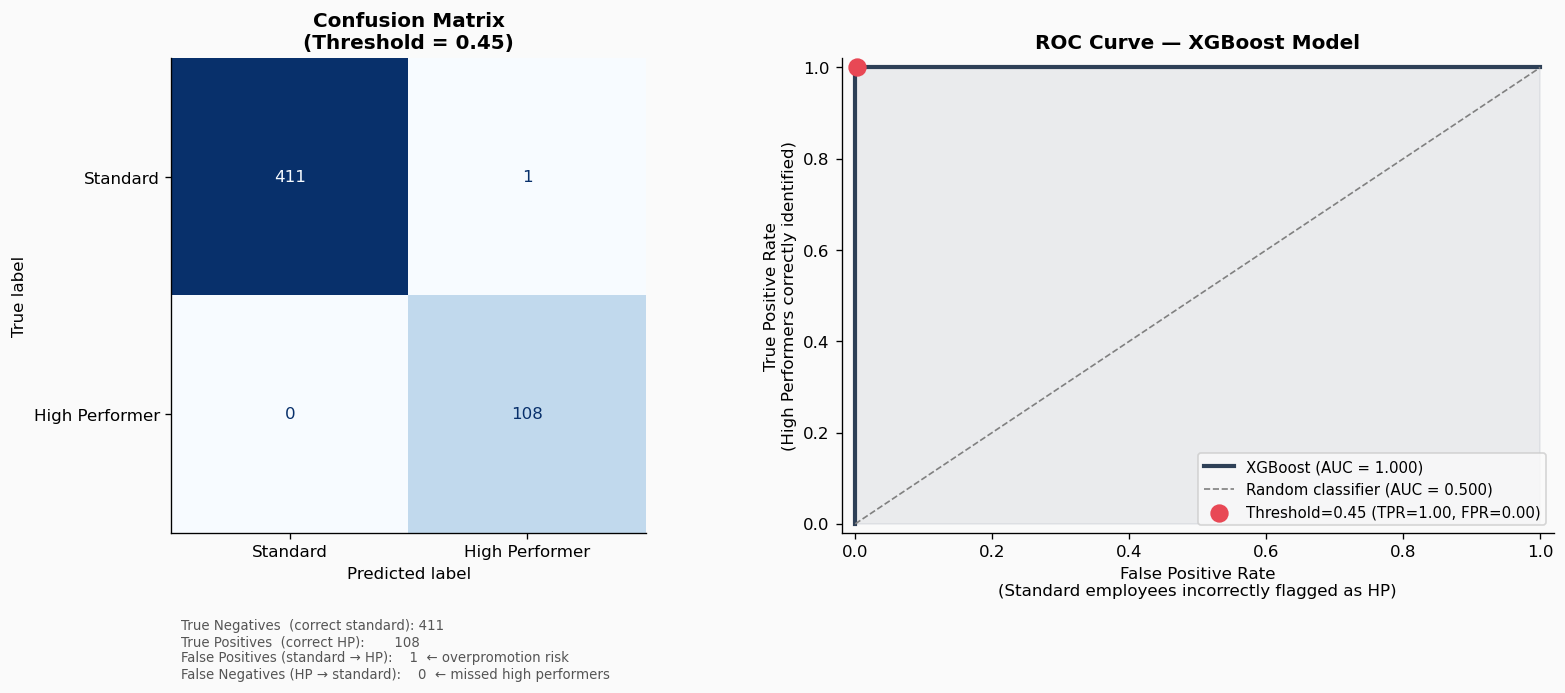

Chart saved: confusion matrix + ROC curve

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Model Evaluation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

CONFUSION MATRIX:
True Positives  : High Performers correctly identified
True Negatives  : Standard employees correctly identified
False Positives : Standard employees flagged as HP
                  Risk = undeserved fast-track treatment
False Negatives : True HPs missed by model
                  Risk = missed promotions, flight risk

AUC = 1.000 means:
If we randomly pick one High Performer and one Standard employee, the model ranks the High Performer
higher 100.0% of the time. An AUC of 0.5 = random guessing. An AUC of 1.0 = perfect predictions.

THRESHOLD CHOICE (0.45 vs 0.50):
In HR, missing a true High Performer (false negative) is more costly than a false positive.
A missed HP may leave

In [9]:
# ── Confusion Matrix and ROC Curve ──

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred_business)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ['Standard', 'High Performer']
)
disp.plot(
    ax        = axes[0],
    colorbar  = False,
    cmap      = 'Blues'
)
axes[0].set_title(
    'Confusion Matrix\n(Threshold = 0.45)',
    fontsize=12
)

# Add business cost annotation
tn, fp, fn, tp = cm.ravel()
axes[0].text(
    0.02, -0.18,
    f"True Negatives  (correct standard): {tn}\n"
    f"True Positives  (correct HP):       {tp}\n"
    f"False Positives (standard → HP):    {fp}  "
    f"← overpromotion risk\n"
    f"False Negatives (HP → standard):    {fn}  "
    f"← missed high performers",
    transform   = axes[0].transAxes,
    fontsize     = 8,
    color        = '#555555',
    verticalalignment = 'top'
)

# ── Right: ROC Curve ──
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

axes[1].plot(
    fpr, tpr,
    color     = C_BLUE,
    linewidth = 2.5,
    label     = f'XGBoost (AUC = {auc_score:.3f})'
)
axes[1].plot(
    [0, 1], [0, 1],
    color     = 'grey',
    linestyle = '--',
    linewidth = 1,
    label     = 'Random classifier (AUC = 0.500)'
)

# Mark our chosen threshold (0.45)
closest_idx = np.argmin(
    np.abs(thresholds - 0.45)
)
axes[1].scatter(
    fpr[closest_idx], tpr[closest_idx],
    color  = C_RED,
    s      = 100,
    zorder = 5,
    label  = f'Threshold=0.45 '
             f'(TPR={tpr[closest_idx]:.2f}, '
             f'FPR={fpr[closest_idx]:.2f})'
)

axes[1].fill_between(fpr, tpr, alpha=0.08, color=C_BLUE)
axes[1].set_title('ROC Curve — XGBoost Model')
axes[1].set_xlabel('False Positive Rate\n'
                    '(Standard employees incorrectly flagged as HP)')
axes[1].set_ylabel('True Positive Rate\n'
                    '(High Performers correctly identified)')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)

plt.tight_layout()
save_path = os.path.join(images_dir, '15_confusion_roc.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print(f"Chart saved: confusion matrix + ROC curve")
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Model Evaluation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

CONFUSION MATRIX:
True Positives  : High Performers correctly identified
True Negatives  : Standard employees correctly identified
False Positives : Standard employees flagged as HP
                  Risk = undeserved fast-track treatment
False Negatives : True HPs missed by model
                  Risk = missed promotions, flight risk

AUC = {auc_score:.3f} means:
If we randomly pick one High Performer and one Standard employee, the model ranks the High Performer
higher {auc_score*100:.1f}% of the time. An AUC of 0.5 = random guessing. An AUC of 1.0 = perfect predictions.

THRESHOLD CHOICE (0.45 vs 0.50):
In HR, missing a true High Performer (false negative) is more costly than a false positive.
A missed HP may leave the company feeling overlooked. So we bias toward higher recall by lowering threshold.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

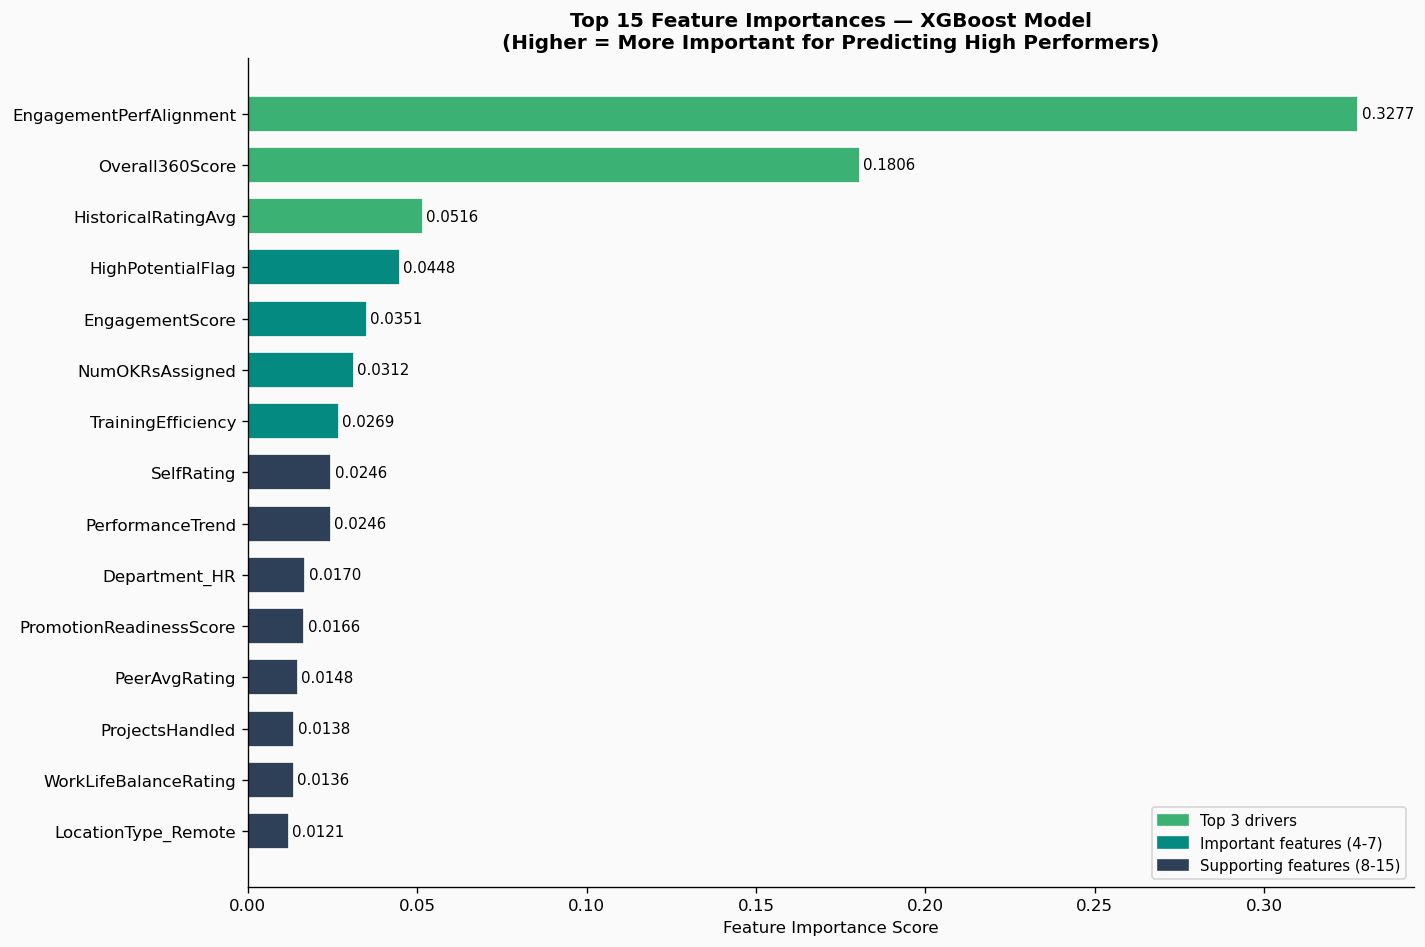

Feature importance chart saved

TOP 10 PERFORMANCE DRIVERS:
Rank   Feature                             Importance  
-------------------------------------------------------
1      EngagementPerfAlignment             0.3277
2      Overall360Score                     0.1806
3      HistoricalRatingAvg                 0.0516
4      HighPotentialFlag                   0.0448
5      EngagementScore                     0.0351
6      NumOKRsAssigned                     0.0312
7      TrainingEfficiency                  0.0269
8      SelfRating                          0.0246
9      PerformanceTrend                    0.0246
10     Department_HR                       0.0170

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Feature Importance
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
The model found the above features most useful for predi

In [10]:
# ── Feature Importance ──

# ── Get feature names after preprocessing ──
numeric_names  = NUMERIC_COLS
ordinal_names  = ORDINAL_COLS
nominal_names  = (preprocessor
                  .named_transformers_['nominal']
                  .named_steps['encoder']
                  .get_feature_names_out(NOMINAL_COLS)
                  .tolist())
binary_names   = BINARY_COLS

all_feature_names = (
    numeric_names +
    ordinal_names +
    nominal_names +
    binary_names
)

# ── Get XGBoost feature importances ──
importances = best_model.feature_importances_

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature'    : all_feature_names[:len(importances)],
    'Importance' : importances
}).sort_values('Importance', ascending=False)

# ── Top 15 features ──
top_15 = importance_df.head(15)

fig, ax = plt.subplots(figsize=(12, 8))

colors_imp = [
    C_GREEN  if i < 3  else
    C_TEAL   if i < 7  else
    C_BLUE
    for i in range(len(top_15))
]

bars = ax.barh(
    top_15['Feature'][::-1],
    top_15['Importance'][::-1],
    color     = colors_imp[::-1],
    edgecolor = 'white',
    height    = 0.7
)

for bar, val in zip(bars, top_15['Importance'][::-1]):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', fontsize=9
    )

ax.set_title('Top 15 Feature Importances — XGBoost Model\n'
             '(Higher = More Important for Predicting High Performers)',
             fontsize=12)
ax.set_xlabel('Feature Importance Score')

# Legend
legend_patches = [
    mpatches.Patch(color=C_GREEN, label='Top 3 drivers'),
    mpatches.Patch(color=C_TEAL,  label='Important features (4-7)'),
    mpatches.Patch(color=C_BLUE,  label='Supporting features (8-15)'),
]
ax.legend(handles=legend_patches, fontsize=9,
          loc='lower right')

plt.tight_layout()
save_path = os.path.join(images_dir, '16_feature_importance.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()

print(f"Feature importance chart saved")
print(f"\nTOP 10 PERFORMANCE DRIVERS:")
print(f"{'Rank':<6} {'Feature':<35} {'Importance':<12}")
print(f"{'-'*55}")
for i, row in importance_df.head(10).iterrows():
    rank = importance_df.index.get_loc(i) + 1
    print(f"{rank:<6} {row['Feature']:<35} {row['Importance']:.4f}")

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Feature Importance
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
The model found the above features most useful for predicting high performer status.

WHAT IT MEANS FOR HR:
The top features are your most actionable levers.
If OKR completion is the top driver — invest in better goal-setting conversations between managers
and employees. If engagement is top — invest in manager training for team engagement practices.

IMPORTANT CAVEAT:
Feature importance shows CORRELATION with high performance — not necessarily causation.
Use these as conversation starters with managers, not as rules to select employees.

HR ACTION:
→ Share top 3 drivers with People Ops leadership.
→ Build manager training programs around top drivers.
→ Review whether underperforming departments lack support in these specific areas.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

In [11]:
# ── Add Predictions to Full Dataset ──

print("Generating predictions for all 2,500 employees...")

# ── Preprocess full dataset ──
X_full = df[FEATURE_COLS].copy()
X_full_processed = preprocessor.transform(X_full)

# ── Generate predictions ──
df['HighPerformerProbability'] = best_model.predict_proba(
    X_full_processed
)[:, 1].round(4)

df['PredictedHighPerformer'] = (
    df['HighPerformerProbability'] >= 0.45
).astype(int)

# ── Prediction confidence band ──
df['PredictionConfidence'] = pd.cut(
    df['HighPerformerProbability'],
    bins   = [0, 0.30, 0.50, 0.70, 0.85, 1.01],
    labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
)

# ── Save enriched dataset ──
predictions_path = os.path.join(
    project_root, 'data', 'processed',
    'employee_with_predictions.csv'
)
df.to_csv(predictions_path, index=False)

# ── Summary ──
predicted_hp = df['PredictedHighPerformer'].sum()
avg_prob     = df['HighPerformerProbability'].mean()

print(f"Predictions generated for all employees")
print(f"\nPredicted High Performers : {predicted_hp:,} "
      f"({predicted_hp/len(df)*100:.1f}%)")
print(f"Average HP Probability    : {avg_prob:.3f}")
print(f"\nConfidence Distribution:")
conf_counts = df['PredictionConfidence'].value_counts().sort_index()
for conf, count in conf_counts.items():
    pct = count / len(df) * 100
    bar = "█" * int(pct / 3)
    print(f"{conf:<12} {count:>5} ({pct:>5.1f}%) {bar}")

print(f"\nEnriched dataset saved:")
print(f"{predictions_path}")
print(f"\nThis file is used by:")
print(f"→ Phase 10: Power BI dashboards")
print(f"→ Phase 11: Monthly automation") 

Generating predictions for all 2,500 employees...
Predictions generated for all employees

Predicted High Performers : 542 (20.8%)
Average HP Probability    : 0.209

Confidence Distribution:
Very Low      2057 ( 79.1%) ██████████████████████████
Low              1 (  0.0%) 
Moderate         3 (  0.1%) 
High             1 (  0.0%) 
Very High      538 ( 20.7%) ██████

Enriched dataset saved:
C:\Users\ganti_kvd0xe3\OneDrive\Sathya\employee_performance_analytics\data\processed\employee_with_predictions.csv

This file is used by:
→ Phase 10: Power BI dashboards
→ Phase 11: Monthly automation


In [12]:
# ── Save the Model ──

# Save trained XGBoost model
joblib.dump(best_model, model_path)

# Save feature column list (needed for automation)
with open(feat_cols_path, 'w') as f:
    json.dump(FEATURE_COLS, f)

# Save model metadata
metadata = {
    'model_type'        : 'XGBoostClassifier',
    'target'            : 'HighPerformer (Rating >= 4.0)',
    'threshold'         : 0.45,
    'n_features'        : len(FEATURE_COLS),
    'train_size'        : int(X_train_processed.shape[0]),
    'test_auc'          : round(float(auc_score), 4),
    'test_f1_business'  : round(float(f1_business), 4),
    'imbalance_ratio'   : round(float(imbalance_ratio), 2),
    'top_5_features'    : importance_df['Feature'].head(5).tolist(),
}

metadata_path = os.path.join(
    project_root, 'models', 'model_metadata.json'
)
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print("-" * 55)
print("ALL MODEL ARTIFACTS SAVED")
print("-" * 55)
print(f"\nModel file     : models/xgb_performance_model.joblib")
print(f"Pipeline file  : models/preprocessing_pipeline.joblib")
print(f"Feature cols   : models/feature_cols.json")
print(f"Metadata       : models/model_metadata.json")
print(f"\nModel Summary:")
for key, val in metadata.items():
    print(f"   {key:<25} : {val}")

print(f"\n{'-'*55}")
print(f"XGBoost model trained and saved")
print(f"AUC = {auc_score:.4f}")
print(f"Ready for Model Evaluation")
print("-" * 55) 

-------------------------------------------------------
ALL MODEL ARTIFACTS SAVED
-------------------------------------------------------

Model file     : models/xgb_performance_model.joblib
Pipeline file  : models/preprocessing_pipeline.joblib
Feature cols   : models/feature_cols.json
Metadata       : models/model_metadata.json

Model Summary:
   model_type                : XGBoostClassifier
   target                    : HighPerformer (Rating >= 4.0)
   threshold                 : 0.45
   n_features                : 41
   train_size                : 2080
   test_auc                  : 1.0
   test_f1_business          : 0.9954
   imbalance_ratio           : 3.8
   top_5_features            : ['EngagementPerfAlignment', 'Overall360Score', 'HistoricalRatingAvg', 'HighPotentialFlag', 'EngagementScore']

-------------------------------------------------------
XGBoost model trained and saved
AUC = 1.0000
Ready for Model Evaluation
-------------------------------------------------------
